# Dilated Causal CNN Decoder for Neural Data

Architecture: stack of dilated causal Conv1D layers over 96-channel SBP at 50ms bins, predicting index finger velocity. Causal padding ensures no future leakage. Trained on first 80% of sessions, tested on last 20%.

## Setup

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = os.path.join('.', 'data', '001201', 'sub-Monkey-N')
nwb_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.nwb')])
print(f'Found {len(nwb_files)} sessions')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

# --- Hyperparameters ---
BIN_SIZE_S   = 0.004
TARGET_BIN_S = 0.050
DOWNSAMPLE   = int(round(TARGET_BIN_S / BIN_SIZE_S))   # 12
N_CHANNELS   = 96
WINDOW       = 20
TRAIN_FRAC   = 0.8
BATCH_SIZE   = 512
EPOCHS       = 30
LR           = 1e-3
MAX_SESSIONS = 312
SEED         = 42

TARGET = 'index_position'

# --- Normalisation modes (set independently) ---
# 'none'    : no transformation
# 'demean'  : subtract per-session mean
# 'zscore'  : subtract per-session mean, divide by per-session std
SBP_NORM    = 'zscore'   # <-- change to compare: 'none' | 'demean' | 'zscore'
TARGET_NORM = 'none'   # <-- change to compare: 'none' | 'demean' | 'zscore'

print(f'Target      : {TARGET}')
print(f'SBP norm    : {SBP_NORM}')
print(f'Target norm : {TARGET_NORM}')

rng = np.random.default_rng(SEED)
all_indices = np.arange(min(MAX_SESSIONS, len(nwb_files)))
rng.shuffle(all_indices)

n_train = int(len(all_indices) * TRAIN_FRAC)
train_indices = sorted(all_indices[:n_train])
test_indices  = sorted(all_indices[n_train:])

print(f'Using {len(all_indices)} sessions  |  Train: {len(train_indices)}  |  Test: {len(test_indices)}')

def downsample_mean(x, factor):
    n = (len(x) // factor) * factor
    return x[:n].reshape(-1, factor).mean(axis=1)

def downsample_mean_2d(X, factor):
    n = (len(X) // factor) * factor
    return X[:n].reshape(-1, factor, X.shape[1]).mean(axis=1)

def normalize_1d(x, mode):
    """Normalize a 1D array. Returns (normalized, loc, scale) for inversion."""
    loc   = float(x.mean())
    scale = float(x.std()) if mode == 'zscore' else 1.0
    if mode == 'none':
        return x.copy(), loc, scale
    elif mode == 'demean':
        return x - loc, loc, scale
    elif mode == 'zscore':
        return (x - loc) / (scale + 1e-8), loc, scale

def normalize_2d(X, mode):
    """Normalize a 2D array (T, C) per-channel. Returns (normalized, loc, scale)."""
    loc   = X.mean(axis=0)                                          # (C,)
    scale = X.std(axis=0) if mode == 'zscore' else np.ones(X.shape[1])
    if mode == 'none':
        return X.copy(), loc, scale
    elif mode == 'demean':
        return X - loc, loc, scale
    elif mode == 'zscore':
        return (X - loc) / (scale + 1e-8), loc, scale


Found 312 NWB files.
Using device: cuda
Target      : index_position
SBP norm    : zscore
Target norm : none
Using 312 sessions  |  Train: 249  |  Test: 63


## Step 1 — Load & Downsample All Sessions

In [7]:
all_sbp_norm  = {}
all_target    = {}
all_tgt_loc   = {}   # per-session target mean  — for inversion at inference
all_tgt_scale = {}   # per-session target std   — for inversion at inference
session_dates = {}

for i in all_indices:
    fname = nwb_files[i]
    path  = os.path.join(DATA_DIR, fname)
    with NWBHDF5IO(path, 'r') as io:
        nwb     = io.read()
        sbp_raw = nwb.analysis['SpikingBandPower'].data[:] / 0.25
        tgt_raw = nwb.analysis[TARGET].data[:].ravel()
        date    = nwb.session_start_time.date()

    sbp_ds = downsample_mean_2d(sbp_raw, DOWNSAMPLE).astype(np.float32)
    tgt_ds = downsample_mean(tgt_raw,    DOWNSAMPLE).astype(np.float32)
    session_dates[i] = date

    sbp_norm, _, _               = normalize_2d(sbp_ds, SBP_NORM)
    tgt_norm, tgt_loc, tgt_scale = normalize_1d(tgt_ds, TARGET_NORM)

    all_sbp_norm[i]  = sbp_norm.astype(np.float32)
    all_target[i]    = tgt_norm.astype(np.float32)
    all_tgt_loc[i]   = tgt_loc
    all_tgt_scale[i] = tgt_scale

    if (list(all_indices).index(i) + 1) % 50 == 0:
        print(f'  [{list(all_indices).index(i)+1}/{len(all_indices)}] session {i}  bins={sbp_ds.shape[0]}')

print(f'\nLoaded {len(all_indices)} sessions')
print(f'SBP norm    : {SBP_NORM}  (per session)')
print(f'Target norm : {TARGET_NORM}  (per session)')


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../data/dandi/001201/sub-Monkey-N/../data/dandi/001201/sub-Monkey-N/sub-Monkey-N_ses-20210407_ecephys.nwb', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Diagnostic — Signal Drift Across Sessions

Check whether the SBP signal itself changes dramatically across sessions. If channels go silent, become noisy, or shift mean/variance over years, cross-session decoding will fail regardless of model.

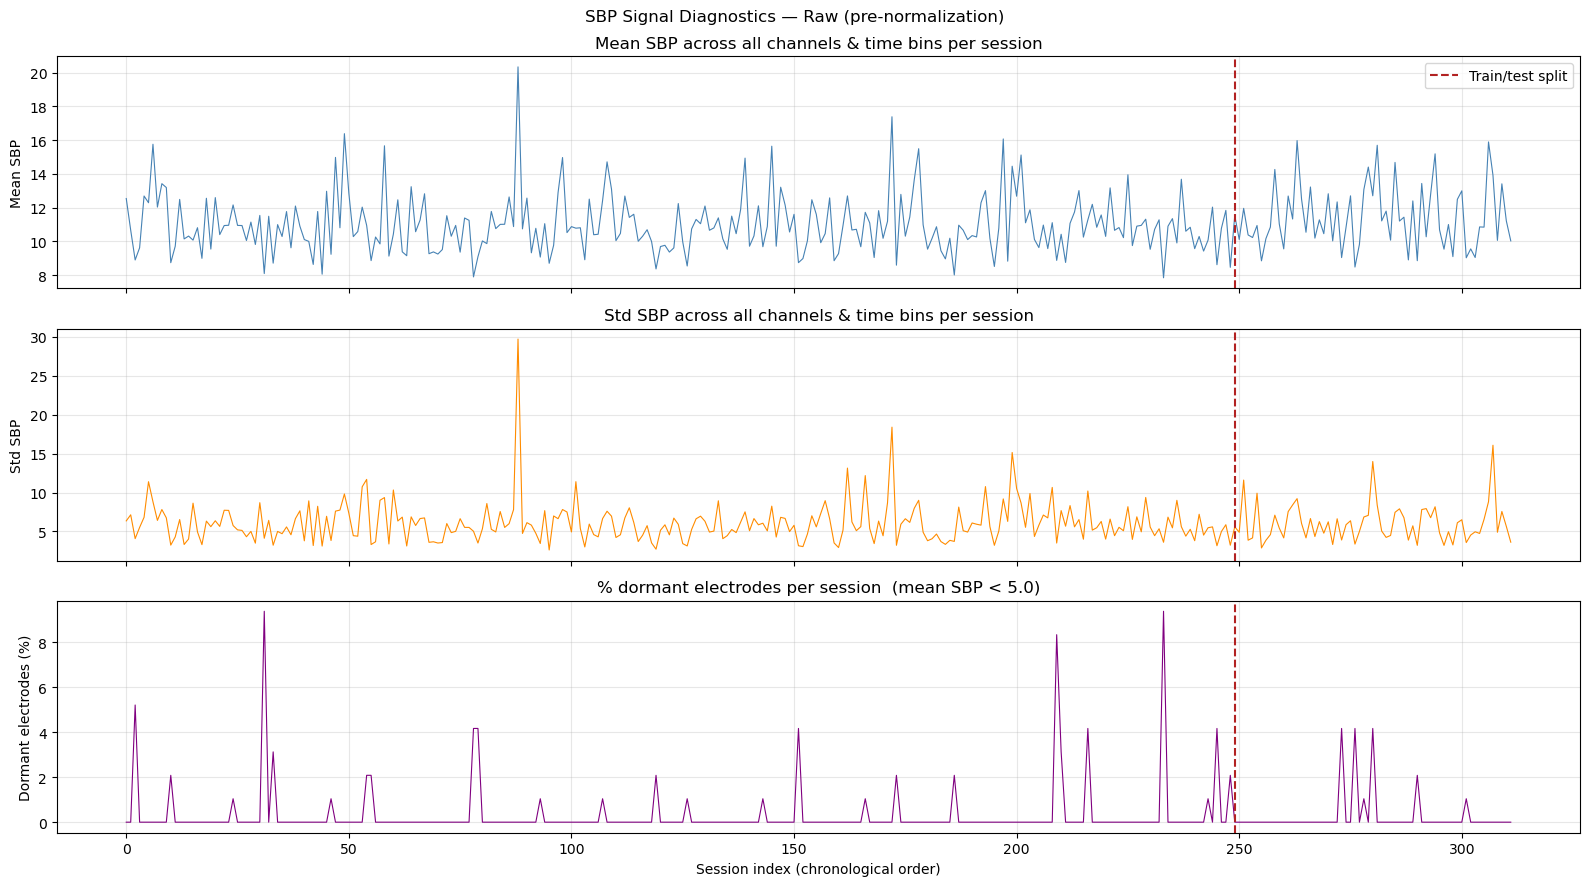

Saved: cnn_signal_drift.png


In [28]:
# Use raw (un-normalized) SBP for drift diagnostics so values are interpretable
all_sbp_raw_diag = {}
for i in all_indices:
    fname = nwb_files[i]
    path  = os.path.join(DATA_DIR, fname)
    with NWBHDF5IO(path, 'r') as io:
        nwb     = io.read()
        sbp_raw = nwb.analysis['SpikingBandPower'].data[:] / 0.25
    all_sbp_raw_diag[i] = downsample_mean_2d(sbp_raw, DOWNSAMPLE).astype(np.float32)

sbp_vals = [all_sbp_raw_diag[i] for i in all_indices]   # (N_sessions,) list of (T, 96)

# --- Per-session summary statistics ---
# Mean across all channels and all time bins
session_mean = np.array([s.mean() for s in sbp_vals])
# Std across all channels and all time bins
session_std  = np.array([s.std()  for s in sbp_vals])
# Dormant electrode: channel whose mean SBP < 5.0 across the session
DORMANT_THRESH = 5.0
session_dormant_pct = np.array([(s.mean(axis=0) < DORMANT_THRESH).mean() * 100
                                for s in sbp_vals])

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
x = np.arange(len(sbp_vals))

axes[0].plot(x, session_mean, lw=0.8, color='steelblue')
axes[0].axvline(n_train, color='firebrick', linestyle='--', label='Train/test split')
axes[0].set_ylabel('Mean SBP')
axes[0].set_title('Mean SBP across all channels & time bins per session')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, session_std, lw=0.8, color='darkorange')
axes[1].axvline(n_train, color='firebrick', linestyle='--')
axes[1].set_ylabel('Std SBP')
axes[1].set_title('Std SBP across all channels & time bins per session')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, session_dormant_pct, lw=0.8, color='purple')
axes[2].axvline(n_train, color='firebrick', linestyle='--')
axes[2].set_ylabel('Dormant electrodes (%)')
axes[2].set_title(f'% dormant electrodes per session  (mean SBP < {DORMANT_THRESH})')
axes[2].set_xlabel('Session index (chronological order)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('SBP Signal Diagnostics — Raw (pre-normalization)', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_signal_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_signal_drift.png')


## Step 2 — Dataset & DataLoader

Each sample is a sliding window of `WINDOW` bins of normalised SBP `(WINDOW, 96)` with the velocity at the last bin as the target. Causal — only past bins are used.

In [29]:
class SBPDataset(Dataset):
    def __init__(self, sbp_list, tgt_list, window):
        self.X, self.y = [], []
        for sbp, tgt in zip(sbp_list, tgt_list):
            T = len(sbp)
            for t in range(window, T):
                self.X.append(sbp[t - window:t])
                self.y.append(tgt[t])
        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)
        print(f'  Dataset: {len(self.X)} samples')

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx].T), torch.tensor(self.y[idx])


print('Building train dataset...')
train_ds = SBPDataset([all_sbp_norm[i] for i in train_indices],
                      [all_target[i]   for i in train_indices], WINDOW)

print('Building test datasets...')
test_ds_list = [
    SBPDataset([all_sbp_norm[i]], [all_target[i]], WINDOW)
    for i in test_indices
]
print(f'  {len(test_ds_list)} test sessions ready.')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE.type != 'cpu'))
print(f'DataLoader: batch_size={BATCH_SIZE}, device={DEVICE}')


Building train dataset...
  Dataset: 504692 samples
Building test datasets...
  Dataset: 2225 samples
  Dataset: 2140 samples
  Dataset: 2414 samples
  Dataset: 2449 samples
  Dataset: 2399 samples
  Dataset: 2384 samples
  Dataset: 2234 samples
  Dataset: 2335 samples
  Dataset: 2228 samples
  Dataset: 1841 samples
  Dataset: 1786 samples
  Dataset: 1898 samples
  Dataset: 1844 samples
  Dataset: 1920 samples
  Dataset: 2917 samples
  Dataset: 2425 samples
  Dataset: 2368 samples
  Dataset: 2335 samples
  Dataset: 2000 samples
  Dataset: 1830 samples
  Dataset: 2236 samples
  Dataset: 2038 samples
  Dataset: 2108 samples
  Dataset: 1779 samples
  Dataset: 1824 samples
  Dataset: 1860 samples
  Dataset: 2073 samples
  Dataset: 2073 samples
  Dataset: 2210 samples
  Dataset: 2142 samples
  Dataset: 2010 samples
  Dataset: 2068 samples
  Dataset: 2056 samples
  Dataset: 1784 samples
  Dataset: 1843 samples
  Dataset: 2036 samples
  Dataset: 1829 samples
  Dataset: 2038 samples
  Dataset:

## Step 3 — Model Architecture

Three dilated causal Conv1D layers with receptive fields of 50ms, 150ms, and 350ms respectively, followed by a pointwise mixing layer and a linear output head.

In [30]:
class CausalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=0)
        self.bn   = nn.BatchNorm1d(out_ch)
        self.act  = nn.ReLU()

    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.pad, 0))
        return self.act(self.bn(self.conv(x)))


class DilatedCausalCNN(nn.Module):
    """
    Input:  (batch, 96, WINDOW)
    Output: (batch,)
    """
    def __init__(self, n_channels=96, filters=64, kernel=3):
        super().__init__()
        self.net = nn.Sequential(
            CausalConvBlock(n_channels, filters, kernel, dilation=1),
            CausalConvBlock(filters,   filters, kernel, dilation=2),
            CausalConvBlock(filters,   filters, kernel, dilation=4),
            nn.Conv1d(filters, 32, kernel_size=1),
            nn.ReLU(),
        )
        self.head = nn.Linear(32, 1)

    def forward(self, x):
        feat = self.net(x)[:, :, -1]
        return self.head(feat).squeeze(1)


model = DilatedCausalCNN(n_channels=N_CHANNELS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print(model)


Model parameters: 45,697
DilatedCausalCNN(
  (net): Sequential(
    (0): CausalConvBlock(
      (conv): Conv1d(96, 64, kernel_size=(3,), stride=(1,))
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
    )
    (1): CausalConvBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
    )
    (2): CausalConvBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(4,))
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
    )
    (3): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
    (4): ReLU()
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
)


## Step 4 — Training

  Epoch   1/30  |  train MSE = 0.023445  |  lr = 9.97e-04
  Epoch   5/30  |  train MSE = 0.013556  |  lr = 9.33e-04
  Epoch  10/30  |  train MSE = 0.011455  |  lr = 7.50e-04
  Epoch  15/30  |  train MSE = 0.010359  |  lr = 5.00e-04
  Epoch  20/30  |  train MSE = 0.009602  |  lr = 2.50e-04
  Epoch  25/30  |  train MSE = 0.009082  |  lr = 6.70e-05
  Epoch  30/30  |  train MSE = 0.008863  |  lr = 0.00e+00

Training complete.


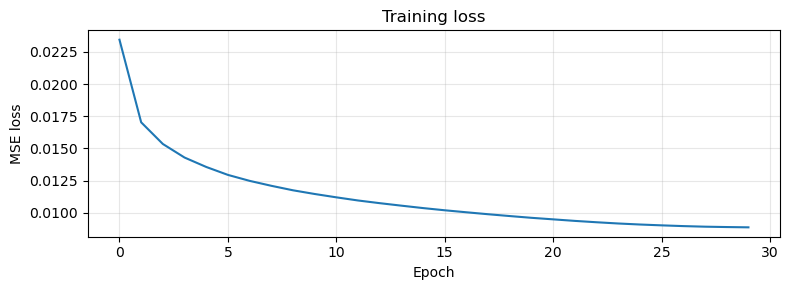

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.MSELoss()

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(y_batch)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS}  |  train MSE = {epoch_loss:.6f}  |  lr = {scheduler.get_last_lr()[0]:.2e}')

print('\nTraining complete.')

plt.figure(figsize=(8, 3))
plt.plot(train_losses, lw=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Cross-Session Evaluation

Test the trained model on each of the last 20% of sessions. One R² per session, plotted as a bar chart over time.

Target : index_position  |  norm : none
Mean R²: -0.4243  |  Std: 3.1968  |  Min: -24.7923  |  Max: 0.7272


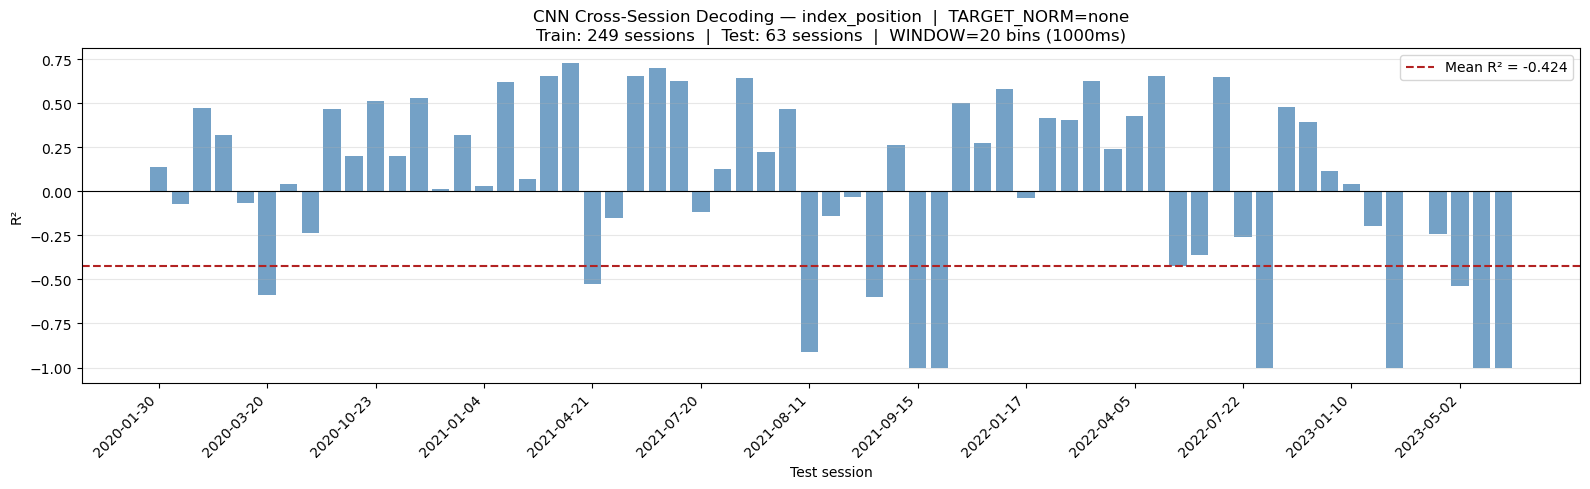

In [24]:
model.eval()
r2_scores  = []
test_dates = [session_dates[i] for i in test_indices]

with torch.no_grad():
    for ds, i in zip(test_ds_list, test_indices):
        loader = DataLoader(ds, batch_size=1024, shuffle=False)
        y_true_norm, y_pred_norm = [], []
        for X_batch, y_batch in loader:
            pred = model(X_batch.to(DEVICE)).cpu().numpy()
            y_pred_norm.extend(pred)
            y_true_norm.extend(y_batch.numpy())
        y_true_norm = np.array(y_true_norm)
        y_pred_norm = np.array(y_pred_norm)

        # invert normalisation back to original [0, 1] space
        loc, scale = all_tgt_loc[i], all_tgt_scale[i]
        y_true = y_true_norm * scale + loc
        y_pred = y_pred_norm * scale + loc

        r2_scores.append(r2_score(y_true, y_pred))

r2_scores = np.array(r2_scores)
print(f'Target : {TARGET}  |  norm : {TARGET_NORM}')
print(f'Mean R²: {r2_scores.mean():.4f}  |  Std: {r2_scores.std():.4f}  |  Min: {r2_scores.min():.4f}  |  Max: {r2_scores.max():.4f}')

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(np.arange(len(r2_scores)), np.clip(r2_scores, -1, None),
       color='steelblue', alpha=0.75, width=0.8)
ax.axhline(r2_scores.mean(), color='firebrick', linewidth=1.5, linestyle='--',
           label=f'Mean R² = {r2_scores.mean():.3f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('R²')
ax.set_xlabel('Test session')
ax.set_title(f'CNN Cross-Session Decoding — {TARGET}  |  TARGET_NORM={TARGET_NORM}\n'
             f'Train: {len(train_indices)} sessions  |  Test: {len(test_indices)} sessions  |  '
             f'WINDOW={WINDOW} bins ({WINDOW*int(TARGET_BIN_S*1000)}ms)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

tick_step = max(1, len(test_dates) // 12)
tick_pos  = np.arange(0, len(test_dates), tick_step)
ax.set_xticks(tick_pos)
ax.set_xticklabels([str(test_dates[i]) for i in tick_pos], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'cnn_cross_session_r2_{TARGET_NORM}.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6 — Prediction vs Actual (Best & Worst Session)

Visual check of what the decoder is actually doing on the best and worst test sessions.

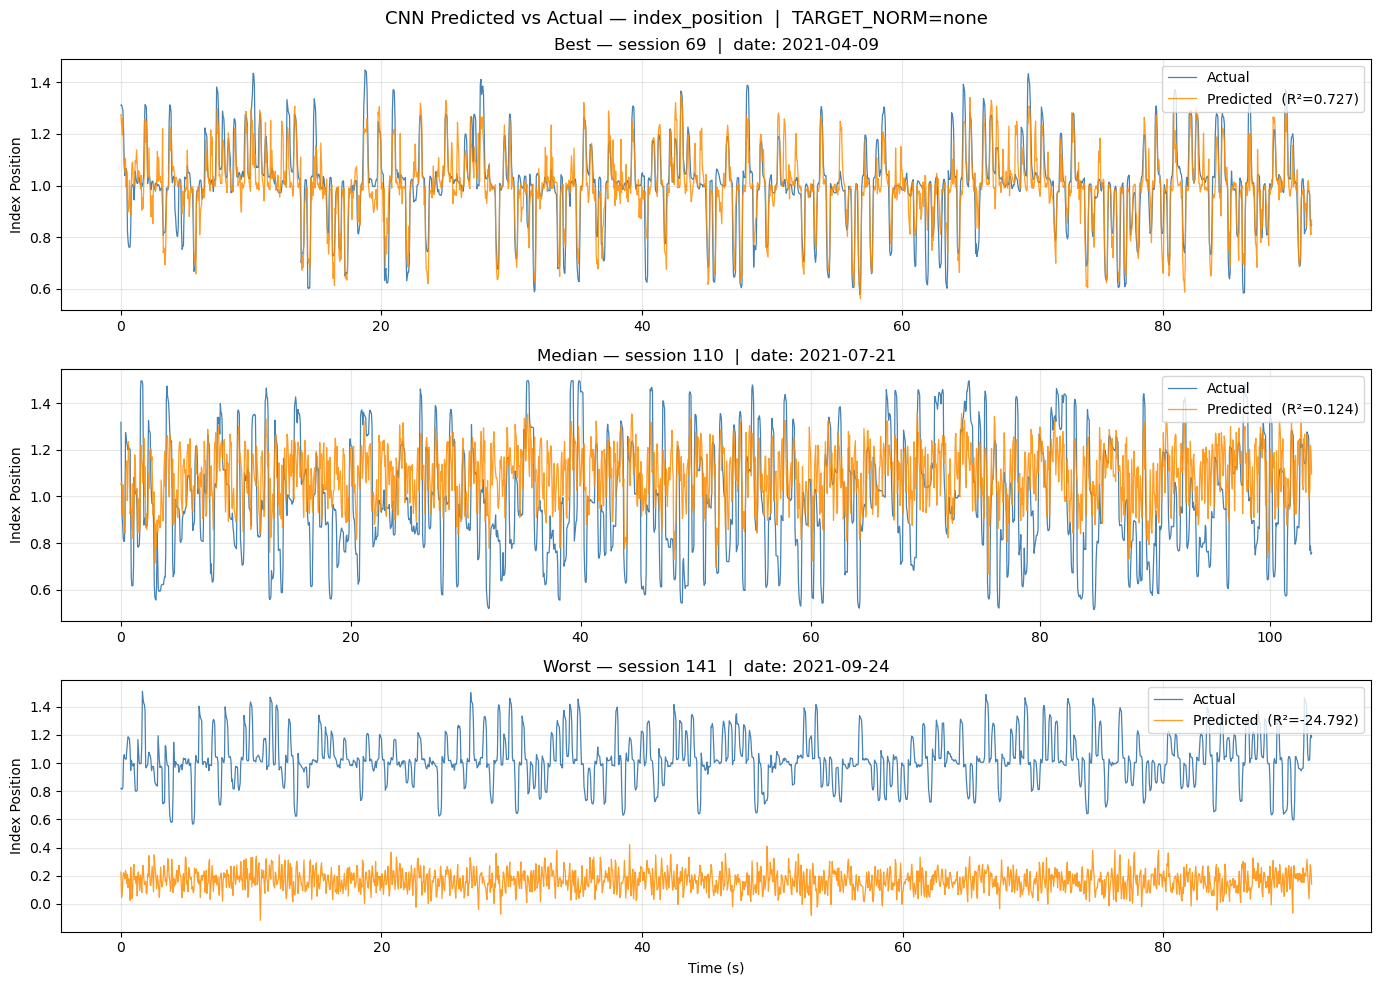

Saved: cnn_predictions_none.png


In [25]:
def get_predictions(ds, session_idx):
    model.eval()
    loader = DataLoader(ds, batch_size=1024, shuffle=False)
    y_true_norm, y_pred_norm = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            pred = model(X_batch.to(DEVICE)).cpu().numpy()
            y_pred_norm.extend(pred)
            y_true_norm.extend(y_batch.numpy())
    loc, scale = all_tgt_loc[session_idx], all_tgt_scale[session_idx]
    y_true = np.array(y_true_norm) * scale + loc
    y_pred = np.array(y_pred_norm) * scale + loc
    return y_true, y_pred

sorted_idx = np.argsort(r2_scores)
display_idx = {
    'Best':   int(sorted_idx[-1]),
    'Median': int(sorted_idx[len(sorted_idx) // 2]),
    'Worst':  int(sorted_idx[0]),
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (label, idx) in zip(axes, display_idx.items()):
    sess_i = test_indices[idx]
    y_true, y_pred = get_predictions(test_ds_list[idx], sess_i)
    time_ax = np.arange(len(y_true)) * TARGET_BIN_S
    ax.plot(time_ax, y_true, lw=0.9, color='steelblue', label='Actual')
    ax.plot(time_ax, y_pred, lw=0.9, color='darkorange', alpha=0.85,
            label=f'Predicted  (R²={r2_scores[idx]:.3f})')
    ax.set_ylabel(TARGET.replace('_', ' ').title())
    ax.set_title(f'{label} — session {sess_i}  |  date: {test_dates[idx]}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'CNN Predicted vs Actual — {TARGET}  |  TARGET_NORM={TARGET_NORM}', fontsize=13)
plt.tight_layout()
plt.savefig(f'cnn_predictions_{TARGET_NORM}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: cnn_predictions_{TARGET_NORM}.png')
